In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
import matplotlib.colors as colors
import matplotlib.patches as patches
import astropy.units as u
import astropy.constants as const
from lmfit.models import gaussian, expgaussian
from scipy.special import erf
from mhealpy import HealpixMap

from random import choices

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
from matplotlib import cycler
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 80})

In [2]:
tiny = 1e-15
s2 = np.sqrt(2)
def expgaussianleft(x, amplitude=1, center=0, sigma=1.0, gamma=1.0):
    '''
    Standard implementation of expgaussian in lmfit.lineshapes is left-skewed

    Here, return a right-skewed, exponentially modified Gaussian.

    For more information, see:
    https://en.wikipedia.org/wiki/Exponentially_modified_Gaussian_distribution
    '''
    gss = -gamma*sigma*sigma
    arg1 = -gamma*(center + gss/2.0 - x)
    arg2 = (center + gss - x)/max(tiny, (s2*sigma))
    return amplitude*(gamma/2) * np.exp(arg1) * (erf(arg2) + 1)

### Visualizing Compton Circle

In [2]:
def spherical_to_cartesian(psi, chi):
    # Convert spherical to Cartesian coordinates
    x = np.sin(psi) * np.cos(chi)
    y = np.sin(psi) * np.sin(chi)
    z = np.cos(psi)
    return np.array([x, y, z])

def cartesian_to_spherical(x, y, z):
    # Convert Cartesian to spherical coordinates
    psi = np.arctan2(np.sqrt(x**2 + y**2), z)  # Inclination angle
    chi = np.arctan2(y, x)  # Azimuth angle
    return psi, chi

def rotate_to_sphere(point, center):
    # Calculate orthogonal basis vectors on the sphere's surface
    z_axis = center / np.linalg.norm(center)  # Normalize center to unit vector
    x_axis = np.cross(z_axis, np.array([0, 0, 1]))
    if np.linalg.norm(x_axis) < 1e-10:
        x_axis = np.array([1, 0, 0])  # Handle the special case when center is (0, 0, 1)
    x_axis /= np.linalg.norm(x_axis)
    y_axis = np.cross(z_axis, x_axis)
    
    # Rotation matrix from tangent plane to sphere surface
    R = np.array([x_axis, y_axis, z_axis]).T
    
    # Rotate the point
    rotated_point = R @ point
    return rotated_point

def circle_on_sphere(psi, chi, phi, num_points=100):
    # Center point in Cartesian coordinates
    center = spherical_to_cartesian(psi, chi)
    
    # Generate circle points on the tangent plane
    angles = np.linspace(0, 2 * np.pi, num_points)
    x_tangent = np.cos(angles) * np.sin(phi)
    y_tangent = np.sin(angles) * np.sin(phi)
    z_tangent = np.cos(phi) * np.ones(num_points)
    
    # Rotate tangent circle points to sphere surface
    circle_points = []
    for i in range(num_points):
        point = np.array([x_tangent[i], y_tangent[i], z_tangent[i]])
        point = rotate_to_sphere(point, center)
        circle_points.append(point)
    
    return np.array(circle_points)

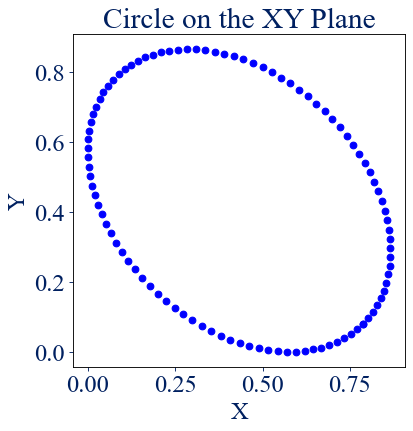

In [3]:
def plot_circle_on_xy_plane(circle_points):
    # Project circle points onto the XY plane
    x = circle_points[:, 0]
    y = circle_points[:, 1]

    plt.figure()
    plt.plot(x, y, 'o')
    plt.title('Circle on the XY Plane')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# Example usage
psi = np.pi / 4  # 45 degrees
chi = np.pi / 4  # 45 degrees
phi = np.pi / 6  # 30 degrees
circle_points = circle_on_sphere(psi, chi, phi)

plot_circle_on_xy_plane(circle_points)

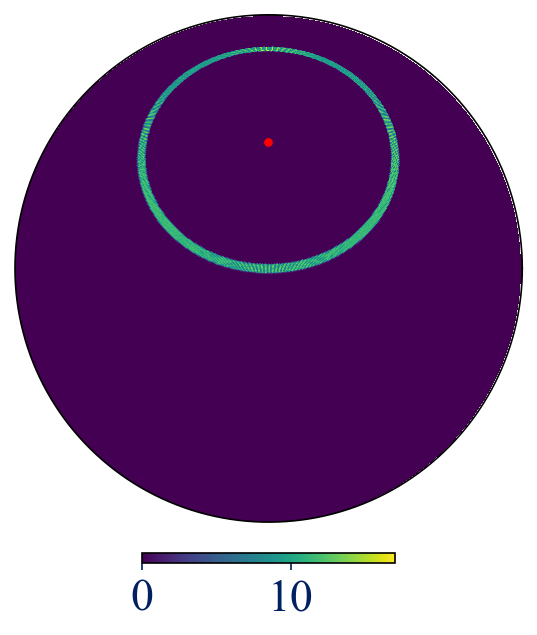

In [4]:
# Define the grid
nside = 256
scheme = 'nested'

# Define the grid and initialize
m = HealpixMap(nside = nside, scheme = scheme, dtype = int)

# Define center of circle
psi = np.pi / 3  # radians
chi = 0  # radians

# Define scatter angle
phi = np.deg2rad(np.linspace(29, 31, 101))

for angle in phi:
    # Ensure input angles are in radians
    circle_points = circle_on_sphere(psi, chi, angle, num_points=800)

    # Get the pixel where a point lands in the current scheme
    theta, phi = cartesian_to_spherical(*circle_points.T)

    # Get the pixel where a point lands in the current scheme
    sample_pix = m.ang2pix(theta, phi)

    # Add the count
    m[sample_pix] += 1

# Plot
fig = plt.figure(dpi = 150)
ax = fig.add_subplot(1,2,1, projection = 'orthview')
m.plot(ax=ax)
ax.scatter(np.rad2deg(chi), 90 - np.rad2deg(psi), marker='o', c='r', s=10, transform=ax.get_transform('world'))

plt.show()

### Visualizing Compton Scatter Angle

In [4]:
m_e = const.m_e
c = const.c
e = const.e.si
eps0 = const.eps0
PI = np.pi
r_e = 1 / (4 * PI * eps0) * (e**2 / (m_e * c**2))
r_e = r_e.to(u.fm)

def Compton_scattering_energy(Ein, phi):
    a = Ein / (m_e * c**2) * (1 - np.cos(phi))
    b = 1 + a   # denominator
    Eout = Ein / b
    return Eout

def Compton_scattering_cross_section(Ein, phi, Eout):
    a = 1/2 * r_e**2 * (Eout/Ein)**2
    b = Ein/Eout + Eout/Ein - np.sin(phi)**2
    return a*b

def Compton_PDF(Ein, phi):
    Eout = Compton_scattering_energy(Ein, phi)
    cross_section = Compton_scattering_cross_section(Ein, phi, Eout)
    pdf = (cross_section[:-1] + cross_section[1:]) / 2 / cross_section.sum() / np.diff(-phi)
    return pdf

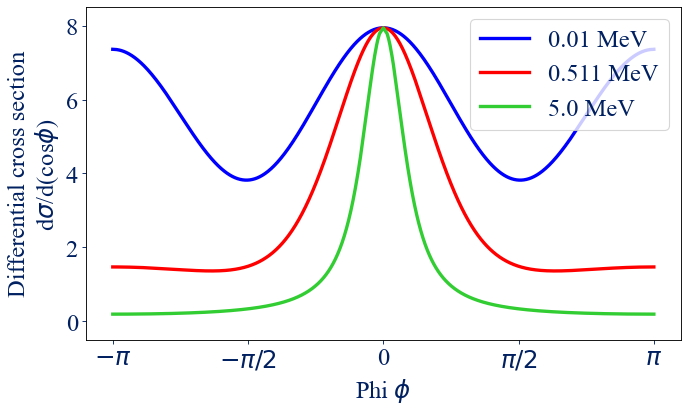

In [11]:
Ein = np.array([0.01, 0.511, 5]) * u.MeV  # TODO: Add whitenoise
# Ein = np.array([1.122, 1.157, 1.192]) * u.MeV

# To ensure that hemisphere is equally sampled
# cosphi = np.random.uniform(-1, 1, 10000)
cosphi = np.linspace(-1, 1, 2001)
phi_sym = np.concatenate([np.arccos(cosphi)[:-1], np.arccos(cosphi) - PI])  # [:-1] to avoid double counting at zero

Eout = np.zeros([Ein.shape[0], phi_sym.shape[0]]) * Ein.unit
cross_section = np.zeros(Eout.shape)
for i, E in enumerate(Ein):
    Eout[i, :] = Compton_scattering_energy(Ein = E, phi = phi_sym)
    cross_section[i, :] = Compton_scattering_cross_section(E, phi_sym, Eout[i, :])
    plt.plot(phi_sym, cross_section[i], label=f'{E}')

plt.xticks([-PI, -PI/2, 0, PI/2, PI])
plt.gca().set_xticklabels([f'$-\\pi$', f'$-\\pi/2$', f'0', f'$\\pi/2$', f'$\\pi$'])
plt.xlabel(f'Phi $\\phi$')
plt.ylabel(f'Differential cross section\nd$\\sigma$/d(cos$\\phi$)')

plt.ylim([-0.5, 8.5])
plt.legend()
plt.show()

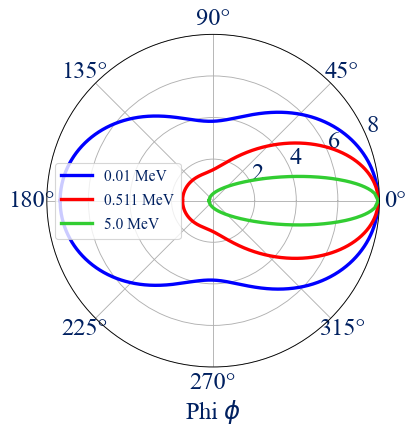

In [12]:
Ein = np.array([0.01, 0.511, 5]) * u.MeV
# Ein = np.array([1.122, 1.157, 1.192]) * u.MeV

for i, E in enumerate(Ein):
    plt.polar(phi_sym, cross_section[i], label=f'{E}')
plt.ylim(top=8)
plt.xlabel(f'Phi $\\phi$')

plt.legend(fontsize=14)
plt.show()

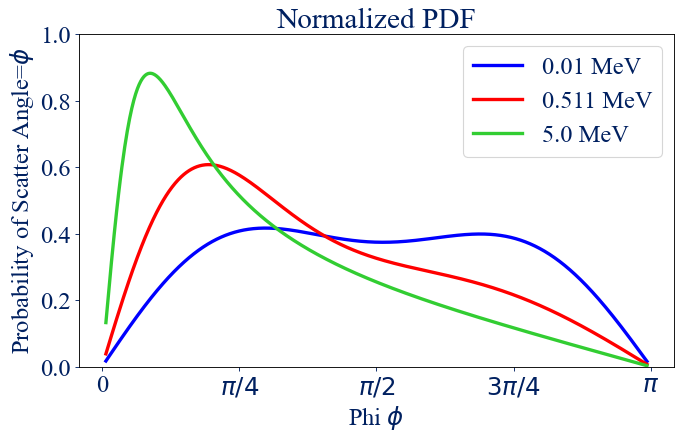

In [ ]:
n = len(phi_sym)//2 + 1
phi = phi_sym[:n]

for i, E in enumerate(Ein):
    bincenters = (phi[:-1] + phi[1:])/2
    pdf = Compton_PDF(E, phi)
    plt.plot(bincenters, pdf, label=f'{E}')

plt.xticks([0, PI/4, PI/2, 3*PI/4, PI])
plt.gca().set_xticklabels([f'0', f'$\\pi/4$', f'$\\pi/2$', f'$3\\pi/4$', f'$\\pi$'])
plt.xlabel(f'Phi $\\phi$')
plt.ylabel(f'Probability of Scatter Angle=$\phi$')
plt.title('Normalized PDF')

plt.ylim([0, 1])
plt.legend()
plt.show()

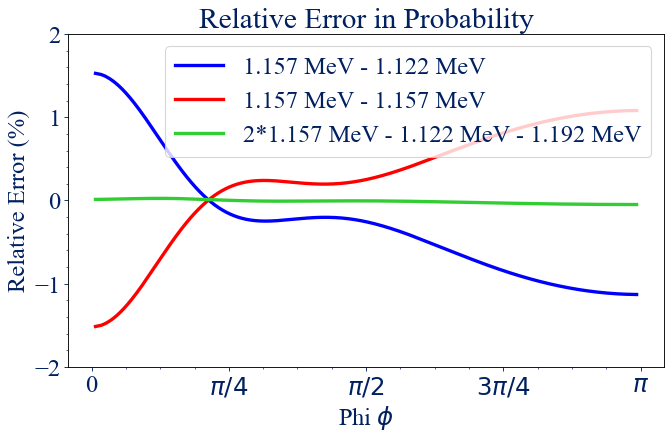

In [ ]:
Ein = np.array([1.154, 1.157, 1.160]) * u.MeV

p = np.zeros([3,len(phi)-1])
for i, E in enumerate(Ein):
    p[i] = Compton_PDF(E, phi)
    
plt.plot(bincenters, (1 - p[0]/p[1])*100, label=f'{Ein[1]} - {Ein[0]}')
plt.plot(bincenters, (1 - p[2]/p[1])*100, label=f'{Ein[1]} - {Ein[1]}')

plt.plot(bincenters, (2 - (p[0]+p[2])/p[1])*100, label=f'2*{Ein[1]} - {Ein[0]} - {Ein[2]}')

plt.xticks([0, PI/4, PI/2, 3*PI/4, PI])
plt.gca().set_xticklabels([f'0', f'$\\pi/4$', f'$\\pi/2$', f'$3\\pi/4$', f'$\\pi$'])
plt.xlabel(f'Phi $\\phi$')
plt.ylabel('Relative Error (%)')
plt.title(f'Relative Error in Probability')

plt.ylim([-2, 2])
plt.minorticks_on()
plt.legend()
plt.show()

### Event Circle Broadening

In [173]:
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 2
np.arange(-11, 12, 2)

array([-11,  -9,  -7,  -5,  -3,  -1,   1,   3,   5,   7,   9,  11])

In [174]:
limrange = np.arange(-13, 14, 2)

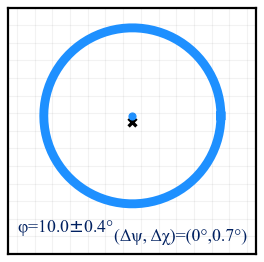

In [175]:
theta = np.deg2rad(np.linspace(0, 360, 181, endpoint=True))
r = 10
# x0 = 0.3
# y0 = 0.2
x0 = 0.04
y0 = 0.7
c = 'dodgerblue'

x = x0 + r * np.cos(theta)
y = y0 + r * np.sin(theta)

plt.figure(figsize=(4,4))
for i in limrange:
    plt.axvline(i, lw=1, alpha=0.1, color='gray')
    plt.axhline(i, lw=1, alpha=0.1, color='gray')
plt.xticks([])
plt.yticks([])
plt.scatter(0, 0, c='k', marker='x', s=50)
plt.plot(x, y, c=c, lw=8)
plt.scatter(x0, y0, c=c, s=40)
plt.xlim([limrange[0]-1, limrange[-1]+1])
plt.ylim([limrange[0]-2, limrange[-1]])
plt.text(limrange[0], limrange[0]+1, f'φ={r*1.0}$\pm$0.4°', va='center', ha='left', fontdict={'fontsize': 16})
plt.text(limrange[-1], limrange[0], f'(Δψ, Δχ)=(0°,{y0:.1f}°)', va='center', ha='right', fontdict={'fontsize': 16})
plt.show()

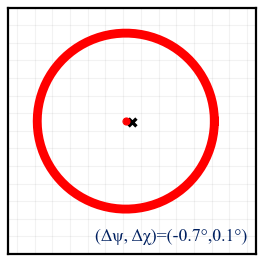

In [176]:
theta = np.deg2rad(np.linspace(0, 360, 181, endpoint=True))
r = 10
# x0 = -0.2
# y0 = 0.4
x0 = -0.7
y0 = 0.1
c = 'red'

x = x0 + r * np.cos(theta)
y = y0 + r * np.sin(theta)

plt.figure(figsize=(4,4))
for i in limrange:
    plt.axvline(i, lw=1, alpha=0.1, color='gray')
    plt.axhline(i, lw=1, alpha=0.1, color='gray')
plt.xticks([])
plt.yticks([])
plt.scatter(0, 0, c='k', marker='x', s=50)
plt.plot(x, y, c=c, lw=8)
plt.scatter(x0, y0, c=c, s=40)
plt.xlim([limrange[0]-1, limrange[-1]+1])
plt.ylim([limrange[0]-2, limrange[-1]])
# plt.text(limrange[0], limrange[0]+1, f'φ={r}°', va='center', ha='left', fontdict={'fontsize': 14})
plt.text(limrange[-1], limrange[0], f'(Δψ, Δχ)=({x0:.1f}°,{y0:.1f}°)', va='center', ha='right', fontdict={'fontsize': 16})
plt.show()

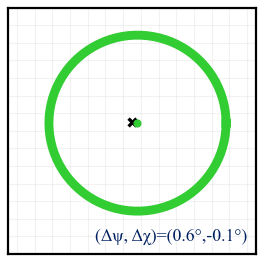

In [177]:
theta = np.deg2rad(np.linspace(0, 360, 181, endpoint=True))
r = 10
# x0 = 0.1
# y0 = -0.3
x0 = 0.62
y0 = -0.13
c = 'limegreen'

x = x0 + r * np.cos(theta)
y = y0 + r * np.sin(theta)

plt.figure(figsize=(4,4))
for i in limrange:
    plt.axvline(i, lw=1, alpha=0.1, color='gray')
    plt.axhline(i, lw=1, alpha=0.1, color='gray')
plt.xticks([])
plt.yticks([])
plt.scatter(0, 0, c='k', marker='x', s=50)
plt.plot(x, y, c=c, lw=8)
plt.scatter(x0, y0, c=c, s=40)
plt.xlim([limrange[0]-1, limrange[-1]+1])
plt.ylim([limrange[0]-2, limrange[-1]])
# plt.text(limrange[0], limrange[0]+1, f'φ={r}°', va='center', ha='left', fontdict={'fontsize': 14})
plt.text(limrange[-1], limrange[0], f'(Δψ, Δχ)=({x0:.1f}°,{y0:.1f}°)', va='center', ha='right', fontdict={'fontsize': 16})
plt.show()

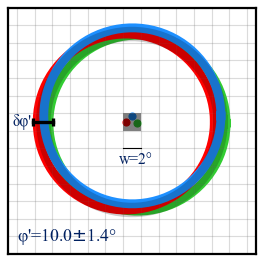

In [214]:
theta = np.deg2rad(np.linspace(0, 360, 181, endpoint=True))
r = 10.
plt.figure(figsize=(4,4))

# for x0, y0, c in zip([0.1, -0.2, 0.3], [-0.3, 0.4, 0.2], ['limegreen', 'red', 'dodgerblue']):
for x0, y0, c in zip([0.62, -0.7, 0.04], [-0.13, 0., 0.7], ['limegreen', 'red', 'dodgerblue']):

    x = x0 + r * np.cos(theta)
    y = y0 + r * np.sin(theta)

    for i in limrange:
        plt.axvline(i, lw=1, alpha=0.1, color='gray')
        plt.axhline(i, lw=1, alpha=0.1, color='gray')
    plt.plot(x, y, c=c, lw=8)
    plt.scatter(x0, y0, c=c, s=40)

plt.fill_between([-1, 1], -1, 1, facecolor='k', alpha=0.5)
x = r * np.cos(theta)
y = r * np.sin(theta)
plt.plot(x, y, c='k', lw=13, alpha=0.2)
plt.xticks([])
plt.yticks([])
plt.xlim([limrange[0]-1, limrange[-1]+1])
plt.ylim([limrange[0]-2, limrange[-1]])
# plt.text(limrange[0], limrange[0]+1, f'φ={r}°', va='center', ha='left', fontdict={'fontsize': 14})
# plt.text(limrange[-1], limrange[0]+1, f'(Δψ, Δχ)=({x0}°,{y0}°)', va='center', ha='right', fontdict={'fontsize': 14})
plt.plot([-1, 1], [-3, -3], c='k', lw=1)
plt.text(x=0.4, y=-3.4, s=f'w=2°', ha='center', va='top', fontdict={'fontsize': 14})
plt.errorbar([-11.2, -8.9], [0]*2, [0.4]*2, c='k', lw=3)
plt.text(x=-11.3, y=0, s=f'δφ\'', ha='right', va='center', fontdict={'fontsize': 14})
plt.text(limrange[0], limrange[0], f'φ\'={r}$\pm$1.4°', va='center', ha='left', fontdict={'fontsize': 16})
plt.show()

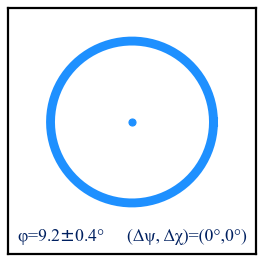

In [197]:
theta = np.deg2rad(np.linspace(0, 360, 181, endpoint=True))
x0 = 0
y0 = 0
r = 9.2
c = 'dodgerblue'

x = x0 + r * np.cos(theta)
y = y0 + r * np.sin(theta)

plt.figure(figsize=(4,4))
plt.plot(x, y, c=c, lw=8)
plt.scatter(x0, y0, c=c, s=40)

# plt.fill_between([-1, 1], -1, 1, facecolor='k', alpha=0.5)
x = r * np.cos(theta)
y = r * np.sin(theta)
# plt.plot(x, y, c='k', lw=10, alpha=0.3)
plt.xticks([])
plt.yticks([])
# plt.scatter(0, 0, c='k', marker='x', s=50)
plt.xlim([limrange[0]-1, limrange[-1]+1])
plt.ylim([limrange[0]-2, limrange[-1]])
plt.text(limrange[0], limrange[0], f'φ={r}$\pm$0.4°', va='center', ha='left', fontdict={'fontsize': 16})
plt.text(limrange[-1], limrange[0], f'(Δψ, Δχ)=({x0}°,{y0}°)', va='center', ha='right', fontdict={'fontsize': 16})
plt.show()

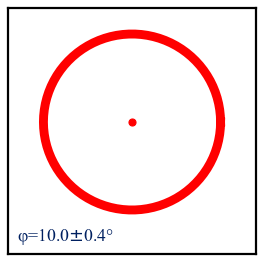

In [198]:
theta = np.deg2rad(np.linspace(0, 360, 181, endpoint=True))
x0 = 0
y0 = 0
r = 10.
c = 'red'

x = x0 + r * np.cos(theta)
y = y0 + r * np.sin(theta)

plt.figure(figsize=(4,4))
plt.plot(x, y, c=c, lw=8)
plt.scatter(x0, y0, c=c, s=40)

# plt.fill_between([-1, 1], -1, 1, facecolor='k', alpha=0.5)
x = r * np.cos(theta)
y = r * np.sin(theta)
# plt.plot(x, y, c='k', lw=10, alpha=0.3)
plt.xticks([])
plt.yticks([])
# plt.scatter(0, 0, c='k', marker='x', s=50)
plt.xlim([limrange[0]-1, limrange[-1]+1])
plt.ylim([limrange[0]-2, limrange[-1]])
plt.text(limrange[0], limrange[0], f'φ={r}$\pm$0.4°', va='center', ha='left', fontdict={'fontsize': 16})
# plt.text(limrange[-1], limrange[0]+1, f'(Δψ, Δχ)=({x0}°,{y0}°)', va='center', ha='right', fontdict={'fontsize': 14})
plt.show()

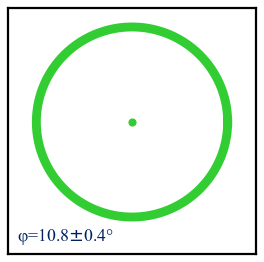

In [199]:
theta = np.deg2rad(np.linspace(0, 360, 181, endpoint=True))
x0 = 0
y0 = 0
r = 10.8
c = 'limegreen'

x = x0 + r * np.cos(theta)
y = y0 + r * np.sin(theta)

plt.figure(figsize=(4,4))
plt.plot(x, y, c=c, lw=8)
plt.scatter(x0, y0, c=c, s=40)

# plt.fill_between([-1, 1], -1, 1, facecolor='k', alpha=0.5)
x = r * np.cos(theta)
y = r * np.sin(theta)
# plt.plot(x, y, c='k', lw=10, alpha=0.3)
plt.xticks([])
plt.yticks([])
# plt.scatter(0, 0, c='k', marker='x', s=50)
plt.xlim([limrange[0]-1, limrange[-1]+1])
plt.ylim([limrange[0]-2, limrange[-1]])
plt.text(limrange[0], limrange[0], f'φ={r}$\pm$0.4°', va='center', ha='left', fontdict={'fontsize': 16})
# plt.text(limrange[-1], limrange[0]+1, f'(Δψ, Δχ)=({x0}°,{y0}°)', va='center', ha='right', fontdict={'fontsize': 14})
plt.show()

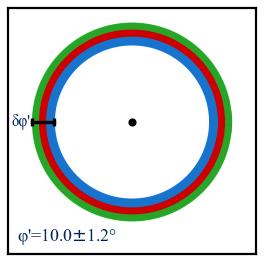

In [208]:
theta = np.deg2rad(np.linspace(0, 360, 181, endpoint=True))
x0 = 0
y0 = 0
plt.figure(figsize=(4,4))

for r, c in zip([10.8, 10, 9.2], ['limegreen', 'red', 'dodgerblue']):

    x = x0 + r * np.cos(theta)
    y = y0 + r * np.sin(theta)

    # for i in np.arange(-11, 12, 2):
    #     plt.axvline(i, lw=1, alpha=0.1, color='gray')
    #     plt.axhline(i, lw=1, alpha=0.1, color='gray')
    plt.plot(x, y, c=c, lw=8)

plt.scatter(x0, y0, c='k', s=40)

# plt.fill_between([-1, 1], -1, 1, facecolor='k', alpha=0.5)
x = 10 * np.cos(theta)
y = 10 * np.sin(theta)
plt.plot(x, y, c='k', lw=20, alpha=0.2)
plt.xticks([])
plt.yticks([])
# plt.scatter(0, 0, c='k', marker='x', s=50)
plt.errorbar([-11.25, -8.85], [0]*2, [0.4]*2, c='k', lw=3)
plt.text(x=-11.5, y=0, s=f'δφ\'', ha='right', va='center', fontdict={'fontsize': 14})
plt.xlim([limrange[0]-1, limrange[-1]+1])
plt.ylim([limrange[0]-2, limrange[-1]])
plt.text(limrange[0], limrange[0], f'φ\'=10.0$\pm$1.2°', va='center', ha='left', fontdict={'fontsize': 16})
# plt.text(limrange[-1], limrange[0]+1, f'(Δψ, Δχ)=({x0}°,{y0}°)', va='center', ha='right', fontdict={'fontsize': 14})
plt.show()

In [98]:
np.sqrt(6/0.86)

2.6413527189768713

In [102]:
8.3/2.64

3.143939393939394

### Adaptive Binning

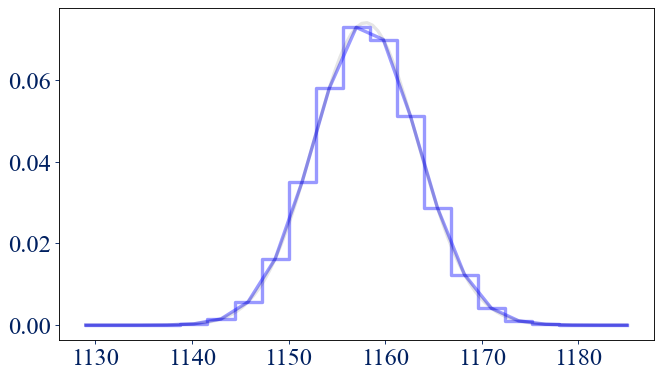

In [17]:
x = np.linspace(1129, 1185, 21)
x0 = np.linspace(x.min(), x.max(), 101)
plt.step(x, expgaussian(x, center=1157, sigma=5.3), where='mid', alpha=0.4)
plt.plot(x, expgaussian(x, center=1157, sigma=5.3), alpha=0.4, c='b')
plt.plot(x0, expgaussian(x0, center=1157, sigma=5.3), alpha=0.1, c='k')
# plt.step(x+1, expgaussian(x+1, center=1157, sigma=5.3), where='mid', alpha=0.4)
# plt.step(x-1, expgaussian(x-1, center=1157, sigma=5.3), where='mid', alpha=0.4)

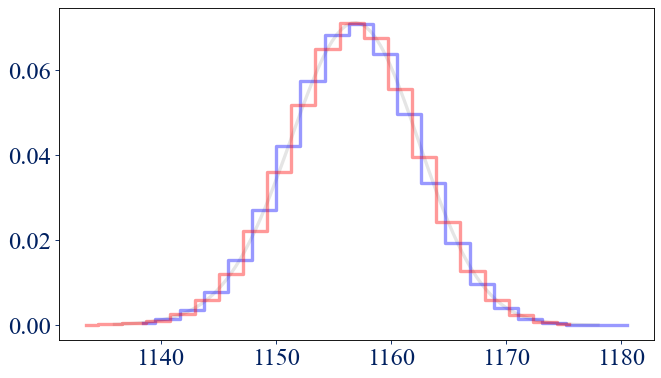

In [43]:
x = np.linspace(1136, 1178, 21)
x0 = np.linspace(x.min(), x.max(), 101)
# plt.step(x, expgaussianleft(x, center=1157, sigma=5.3), where='mid', alpha=0.4)
# plt.plot(x, expgaussianleft(x, center=1157, sigma=5.3), alpha=0.4, c='b')
plt.plot(x0, expgaussianleft(x0, center=1157+1.7, sigma=5.3, gamma=0.5), alpha=0.1, c='k')
plt.step(x+2.5, expgaussianleft(x+2.5, center=1157+1.7, sigma=5.3, gamma=0.5), where='mid', alpha=0.4)
plt.step(x-2.5, expgaussianleft(x-2.5, center=1157+1.7, sigma=5.3, gamma=0.5), where='mid', alpha=0.4)

In [26]:
np.sqrt((58/2.355)**2 + (9/2.355)**2)

24.923194209476332

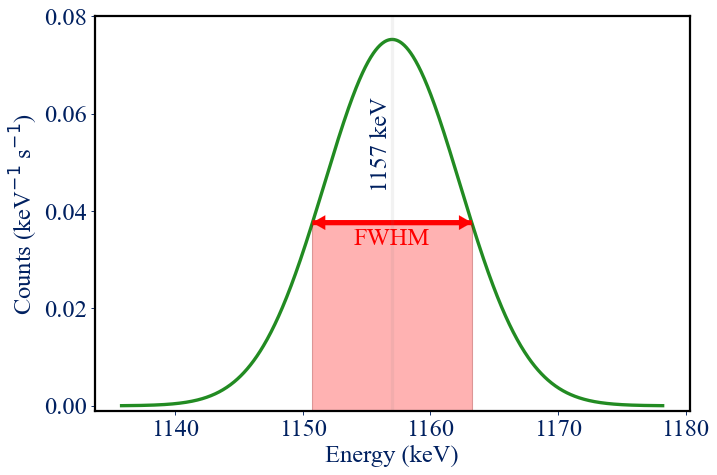

In [79]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 2

# Parameters for the Gaussian distribution
mu = 1157  # mean
sigma = 5.3  # standard deviation

# Create an array of x values
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Create the Gaussian distribution
amplitude = 1/(sigma * np.sqrt(2 * np.pi))
y = amplitude * np.exp(-0.5 * ((x - mu)/sigma)**2)

# Calculate FWHM
fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma

# Get the value of the Gaussian at FWHM/2
height = amplitude * np.exp(-0.5 * ((fwhm/2)/sigma)**2)

# Uniform background value
background = 0#100 * amplitude

plt.figure(figsize=(9.6, 6.4))

# Plot the Gaussian with background
plt.plot(x, y + background, c='forestgreen', label='Gaussian signal', zorder=1)
plt.axvline(mu, alpha=0.1, c='gray')
plt.text(mu, 0.045, '1157 keV', rotation=90, ha='right')

# Add a truncated rectangle to denote the FWHM region
plt.fill_betweenx([background - 0.01, background + height], mu - fwhm/2, mu + fwhm/2, color='red', alpha=0.3, label='FWHM region', edgecolor='darkred')
plt.ylim([-0.001, 0.08])
plt.text(mu, background + height - 0.001, 'FWHM', color='r', va='top', ha='center')
plt.arrow(mu - fwhm/2, background + height, fwhm, 0, 
          head_width = 0.003, head_length = 1, length_includes_head = True, 
          color='r', lw=0.1)
plt.arrow(mu + fwhm/2, background + height, -fwhm, 0, 
          head_width = 0.003, head_length = 1, length_includes_head = True, 
          color='r', lw=0.1)

# Add labels and legend
plt.xlabel('Energy (keV)')
plt.ylabel('Counts (keV$^{-1}$ s$^{-1}$)')
# plt.ylabel('Probability Density')
# plt.title('Gaussian Distribution with Background and Truncated FWHM Region')
# plt.legend(loc='upper right', fontsize=14)

# Show the plot
plt.show()


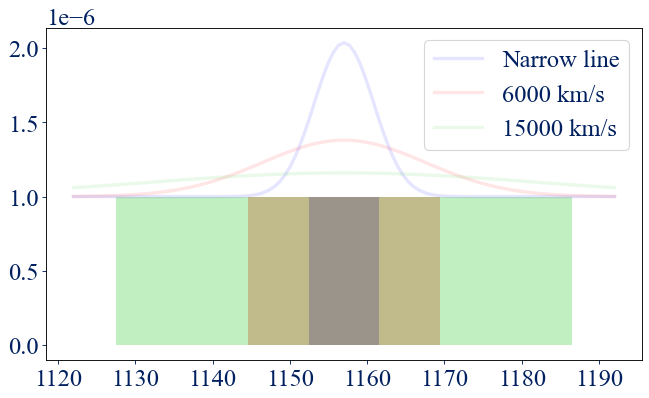

In [65]:
x = np.linspace(1122, 1192, 101)
bg = 1e-6

amp = 1e-5
mu = 1157  # mean
sigma = 3.85  # standard deviation

for sigma, label in zip([3.85, 10.5, 25], ['Narrow line', '6000 km/s', '15000 km/s']):
# for sigma, label in zip([3.85], ['Narrow line']):
    y = gaussian(x, amp, mu, sigma) + bg
    plt.plot(x, y, alpha=0.1, label=label)

    fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma
    height = amp * np.exp(-0.5 * ((fwhm/2)/sigma)**2)
    plt.fill_betweenx([0, bg], mu - fwhm/2, mu + fwhm/2, alpha=0.3)

absdiff = np.abs(1157-x0)
# plt.plot(x, bg + gaussian(0, amplitude=1e-5, sigma=3.85)/2*np.where(absdiff <= 5, 1, 0))
plt.legend()
# plt.ylim([])
plt.show()

### Flux Sensitivity

In [3]:
9/2.355, 15e3/3e5*1157/2.355

(3.821656050955414, 24.56475583864119)

In [3]:
def F(M, d, t):
    return 5.5e-5 * (M/1e-5) * (d/4)**(-2) * np.exp(-t/86)

In [4]:
def calc_d(F, M, t):
    return 4*np.sqrt((5.5e-5/F) * (M/1e-5) * np.exp(-t/86))

In [5]:
F(2.4e-4,3.4,340) * 0.999

3.502058397358267e-05

In [6]:
SNR = np.array(['G1.9+0.3', 'Kepler', 'Tycho', 'SN 1181', 'SN 1885A (M31)',
                'SNR 0509-67.5 (LMC)', 'SNR 0519-69.0 (LMC)',
                'SN 1006', 
                ])
M = np.array([1e-5, 1e-4, 1e-4, 1e-2, 1e-2, 1e-4, 1e-4, 
              1e-4
              ])
d = np.array([8.5, 5.0, 2.75, 2.3, 766, 49, 50, 
              2.18
              ])
derr = np.array([0,1,0.25,0.14,60, 3, 5, 
                 0.1
                 ])
t = 2028 - np.array([1898, 1604, 1572, 1181, 1885, 1718, 1428, 
                     1006
                     ])
terr = np.array([8,0,0,0,0,30,50,
                 0
                 ])

# SNR = np.array(['G1.9+0.3', 'Kepler', 'Tycho', 'SN 1181', 'SN 1885A'])
# M = np.array([1e-5, 1e-4, 1e-4, 1e-2, 1e-2])
# d = np.array([8.5, 5.0, 2.75, 2.3, 766])
# derr = np.array([0,1,0.25,0.14,60])
# t = 2028 - np.array([1898, 1604, 1572, 1181, 1885])
# terr = np.array([8,0,0,0,0])

In [7]:
F(M,d,t)

array([2.68629165e-06, 2.54313766e-06, 5.79490797e-06, 8.78478925e-06,
       2.84370347e-07, 9.96805448e-08, 3.28534636e-09, 1.27801297e-08])

In [8]:
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 2

In [9]:
np.sqrt((5e3/3e5*1157/2.355)**2 + 3.85**2)

9.048202580329031

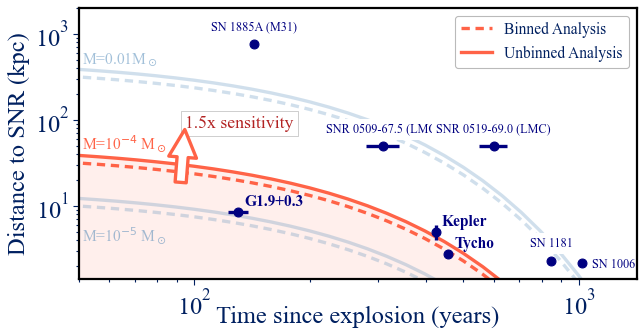

In [10]:
ts = np.logspace(1, 3.3, 47)
Fs = 5.0e-6 # 8.3e-6 * np.sqrt(2.1/6.5)
Fs1 = Fs/1.5
plt.figure(figsize=(9, 4.4))
# plt.figure(figsize=(11, 4))
ax = plt.gca()

dash_ls = (0,(2.5,1.7))
fade_alpha = 0.25
mec = 'navy'

c1 = 'steelblue'

c1 = 'steelblue'
# Ms = 1e-1
# ds = calc_d(Fs1, Ms, ts)
# plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
# plt.text(ts[15]/1.1, ds[15]*1.24, f'M=0.1M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

Ms = 1e-2
ds = calc_d(Fs, Ms, ts)
plt.plot(ts, ds, c=c1, ls=dash_ls, alpha=fade_alpha)
ds = calc_d(Fs1, Ms, ts)
plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
plt.text(ts[15]/1.1, ds[15]*1.24, f'M=0.01M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

# Ms = 1e-3
# ds = calc_d(Fs1, Ms, ts)
# plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
# plt.text(ts[15]/1.1, ds[15]*1.24, f'M=10$^{{-3}}$ M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

Ms = 1e-5
ds = calc_d(Fs, Ms, ts)
plt.plot(ts, ds, c=c1, ls=dash_ls, alpha=fade_alpha)
ds = calc_d(Fs1, Ms, ts)
plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
plt.text(ts[15]/1.1, ds[15]/3, f'M=10$^{{-5}}$ M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

c2 = 'tomato'
Ms = 1e-4
ds = calc_d(Fs, Ms, ts)
plt.plot(ts, ds, c=c2, ls=dash_ls, label='Binned Analysis')
ds = calc_d(Fs1, Ms, ts)
plt.plot(ts, ds, c=c2, label='Unbinned Analysis')#, label='>10$^{-4}$M$_\odot$')#$^{\mathrm{44}}$Ti
plt.text(ts[15]/1.1, ds[15]*1.24, f'M=10$^{{-4}}$ M$_\odot$', fontdict=dict(fontsize=14, color=c2, alpha=1))

# x_tail = 60
# y_tail = 110
# x_head = 60
# y_head = 25
# arrow = patches.FancyArrowPatch((x_tail, y_tail), (x_head, y_head),
#                                  facecolor='w',
#                                  edgecolor='r',
#                                  linewidth=3,
#                                  mutation_scale=50)
# ax.add_patch(arrow)

x_tail = 92
y_tail = 22 * 4/5
x_head = 94.5
y_head = 102 * 4/5
arrow = patches.FancyArrowPatch((x_tail, y_tail), (x_head, y_head),
                                 facecolor='w',
                                 edgecolor=c2,
                                 linewidth=3,
                                 mutation_scale=50,
                                 zorder=10)
ax.add_patch(arrow)
plt.text(x_head, y_head, '1.5x sensitivity',
         bbox=dict(facecolor=(1,1,1,1), edgecolor='darkgray', lw=0.5), 
         fontdict=dict(fontsize=16, color='firebrick')
         )

ts = np.logspace(1, 3, 401)
ds = calc_d(Fs1, Ms, ts)
for i in range(1, len(ts)):
    plt.fill_between([ts[i-1], ts[i]], 0, ds[i], facecolor=c2, alpha=0.1)

for i in range(3):
    plt.text(t[i]*1.04, d[i]*1.17, SNR[i], ha='left', weight='bold', fontdict=dict(fontsize=14, color=mec),
            #  bbox=dict(facecolor=colors.to_rgba('white')[:-1]+(0.0,),       # Truncated and re-appended alpha=0 for facecolor
            #            edgecolor='', linewidth=1.5)
                       )

for i in range(3,7):
    plt.text(t[i]*1, d[i]*1.45, SNR[i], ha='center', fontdict=dict(fontsize=11, color=mec),
             bbox=dict(facecolor='white', edgecolor='none'))
plt.text(t[-1]*1.06, d[-1]/1.15, SNR[-1], ha='left', fontdict=dict(fontsize=11, color=mec),
            # bbox=dict(facecolor='white', edgecolor='none')
            )

plt.errorbar(t, d, xerr=terr, yerr=derr, fmt='o',  
             markerfacecolor=mec, markersize=8, markeredgecolor=mec, ecolor='navy', capsize=0)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time since explosion (years)')
ax.xaxis.set_label_coords(x=0.5, y=-0.1)
plt.ylabel('Distance to SNR (kpc)')
plt.xlim(left=50, right=1.414e3)
plt.ylim(bottom=1.414, top=2e3)
# ax.set_xticks([1e2, 3e2, 1e3])
# ax.set_xticklabels([100, 300, 1000])
ax.xaxis.set_tick_params(width=1, size=3, which='minor')
ax.yaxis.set_tick_params(width=1, size=3, which='minor')
ax.xaxis.set_tick_params(width=1, size=5, which='major')
ax.yaxis.set_tick_params(width=1, size=5, which='major')

plt.legend(loc='upper right', fontsize=14, edgecolor='darkgray')
plt.show()

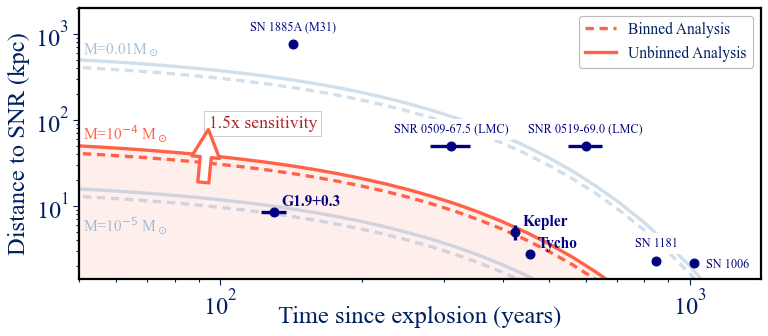

In [32]:
ts = np.logspace(1, 3.3, 47)
Fs = 3.0e-6 # 8.3e-6 * np.sqrt(2.1/6.5). Used 5.0e-6 for FINESST 2025.
Fs1 = Fs/1.5
plt.figure(figsize=(11, 4.4))
# plt.figure(figsize=(11, 4))
ax = plt.gca()

dash_ls = (0,(2.5,1.7))
fade_alpha = 0.25
mec = 'navy'

c1 = 'steelblue'

c1 = 'steelblue'
# Ms = 1e-1
# ds = calc_d(Fs1, Ms, ts)
# plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
# plt.text(ts[15]/1.1, ds[15]*1.24, f'M=0.1M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

Ms = 1e-2
ds = calc_d(Fs, Ms, ts)
plt.plot(ts, ds, c=c1, ls=dash_ls, alpha=fade_alpha)
ds = calc_d(Fs1, Ms, ts)
plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
plt.text(ts[15]/1.1, ds[15]*1.24, f'M=0.01M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

# Ms = 1e-3
# ds = calc_d(Fs1, Ms, ts)
# plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
# plt.text(ts[15]/1.1, ds[15]*1.24, f'M=10$^{{-3}}$ M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

Ms = 1e-5
ds = calc_d(Fs, Ms, ts)
plt.plot(ts, ds, c=c1, ls=dash_ls, alpha=fade_alpha)
ds = calc_d(Fs1, Ms, ts)
plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
plt.text(ts[15]/1.1, ds[15]/3, f'M=10$^{{-5}}$ M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

c2 = 'tomato'
Ms = 1e-4
ds = calc_d(Fs, Ms, ts)
plt.plot(ts, ds, c=c2, ls=dash_ls, label='Binned Analysis')
ds = calc_d(Fs1, Ms, ts)
plt.plot(ts, ds, c=c2, label='Unbinned Analysis')#, label='>10$^{-4}$M$_\odot$')#$^{\mathrm{44}}$Ti
plt.text(ts[15]/1.1, ds[15]*1.24, f'M=10$^{{-4}}$ M$_\odot$', fontdict=dict(fontsize=14, color=c2, alpha=1))

# x_tail = 60
# y_tail = 110
# x_head = 60
# y_head = 25
# arrow = patches.FancyArrowPatch((x_tail, y_tail), (x_head, y_head),
#                                  facecolor='w',
#                                  edgecolor='r',
#                                  linewidth=3,
#                                  mutation_scale=50)
# ax.add_patch(arrow)

x_tail = 92
y_tail = 22 * 4/5
x_head = 94.5
y_head = 102 * 4/5
arrow = patches.FancyArrowPatch((x_tail, y_tail), (x_head, y_head),
                                 facecolor='w',
                                 edgecolor=c2,
                                 linewidth=3,
                                 mutation_scale=50,
                                 zorder=10)
ax.add_patch(arrow)
plt.text(x_head, y_head, '1.5x sensitivity',
         bbox=dict(facecolor=(1,1,1,1), edgecolor='darkgray', lw=0.5), 
         fontdict=dict(fontsize=16, color='firebrick')
         )

ts = np.logspace(1, 3, 401)
ds = calc_d(Fs1, Ms, ts)
for i in range(1, len(ts)):
    plt.fill_between([ts[i-1], ts[i]], 0, ds[i], facecolor=c2, alpha=0.1)

for i in range(3):
    plt.text(t[i]*1.04, d[i]*1.17, SNR[i], ha='left', weight='bold', fontdict=dict(fontsize=14, color=mec),
            #  bbox=dict(facecolor=colors.to_rgba('white')[:-1]+(0.0,),       # Truncated and re-appended alpha=0 for facecolor
            #            edgecolor='', linewidth=1.5)
                       )

for i in range(3,7):
    plt.text(t[i]*1, d[i]*1.45, SNR[i], ha='center', fontdict=dict(fontsize=11, color=mec),
             bbox=dict(facecolor='white', edgecolor='none'))
plt.text(t[-1]*1.06, d[-1]/1.15, SNR[-1], ha='left', fontdict=dict(fontsize=11, color=mec),
            # bbox=dict(facecolor='white', edgecolor='none')
            )

plt.errorbar(t, d, xerr=terr, yerr=derr, fmt='o',  
             markerfacecolor=mec, markersize=8, markeredgecolor=mec, ecolor='navy', capsize=0)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time since explosion (years)')
ax.xaxis.set_label_coords(x=0.5, y=-0.1)
plt.ylabel('Distance to SNR (kpc)')
plt.xlim(left=50, right=1.414e3)
plt.ylim(bottom=1.414, top=2e3)
# ax.set_xticks([1e2, 3e2, 1e3])
# ax.set_xticklabels([100, 300, 1000])
ax.xaxis.set_tick_params(width=1, size=3, which='minor')
ax.yaxis.set_tick_params(width=1, size=3, which='minor')
ax.xaxis.set_tick_params(width=1, size=5, which='major')
ax.yaxis.set_tick_params(width=1, size=5, which='major')

plt.legend(loc='upper right', fontsize=14, edgecolor='darkgray')
plt.show()

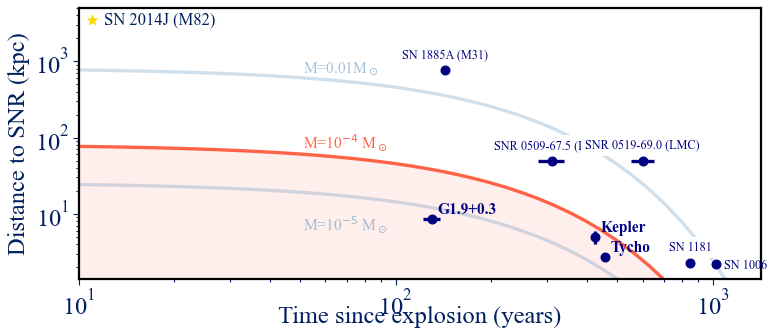

In [33]:
ts = np.logspace(1, 3.3, 47)
Fs = 2.0e-6 # 8.3e-6 * np.sqrt(2.1/6.5). Used 5.0e-6 for FINESST 2025.
Fs1 = Fs/1.5
plt.figure(figsize=(11, 4.4))
# plt.figure(figsize=(11, 4))
ax = plt.gca()

dash_ls = (0,(2.5,1.7))
fade_alpha = 0.25
mec = 'navy'

c1 = 'steelblue'

c1 = 'steelblue'
# Ms = 1e-1
# ds = calc_d(Fs1, Ms, ts)
# plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
# plt.text(ts[15]/1.1, ds[15]*1.24, f'M=0.1M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

Ms = 1e-2
ds = calc_d(Fs, Ms, ts)
# plt.plot(ts, ds, c=c1, ls=dash_ls, alpha=fade_alpha)
ds = calc_d(Fs1, Ms, ts)
plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
plt.text(ts[15]/1.1, ds[15]*1.24, f'M=0.01M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

# Ms = 1e-3
# ds = calc_d(Fs1, Ms, ts)
# plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
# plt.text(ts[15]/1.1, ds[15]*1.24, f'M=10$^{{-3}}$ M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

Ms = 1e-5
ds = calc_d(Fs, Ms, ts)
# plt.plot(ts, ds, c=c1, ls=dash_ls, alpha=fade_alpha)
ds = calc_d(Fs1, Ms, ts)
plt.plot(ts, ds, c=c1, alpha=fade_alpha)#, label='>10$^{-2}$M$_\odot$')
plt.text(ts[15]/1.1, ds[15]/3, f'M=10$^{{-5}}$ M$_\odot$', fontdict=dict(fontsize=14, color=c1, alpha=fade_alpha*2))

c2 = 'tomato'
Ms = 1e-4
ds = calc_d(Fs, Ms, ts)
# plt.plot(ts, ds, c=c2, ls=dash_ls, label='Binned Analysis')
ds = calc_d(Fs1, Ms, ts)
plt.plot(ts, ds, c=c2, label='Unbinned Analysis')#, label='>10$^{-4}$M$_\odot$')#$^{\mathrm{44}}$Ti
plt.text(ts[15]/1.1, ds[15]*1.24, f'M=10$^{{-4}}$ M$_\odot$', fontdict=dict(fontsize=14, color=c2, alpha=1))

# x_tail = 60
# y_tail = 110
# x_head = 60
# y_head = 25
# arrow = patches.FancyArrowPatch((x_tail, y_tail), (x_head, y_head),
#                                  facecolor='w',
#                                  edgecolor='r',
#                                  linewidth=3,
#                                  mutation_scale=50)
# ax.add_patch(arrow)

# x_tail = 92
# y_tail = 22 * 4/5
# x_head = 94.5
# y_head = 102 * 4/5
# arrow = patches.FancyArrowPatch((x_tail, y_tail), (x_head, y_head),
#                                  facecolor='w',
#                                  edgecolor=c2,
#                                  linewidth=3,
#                                  mutation_scale=50,
#                                  zorder=10)
# ax.add_patch(arrow)
# plt.text(x_head, y_head, '1.5x sensitivity',
#          bbox=dict(facecolor=(1,1,1,1), edgecolor='darkgray', lw=0.5), 
#          fontdict=dict(fontsize=16, color='firebrick')
#          )

ts = np.logspace(1, 3, 401)
ds = calc_d(Fs1, Ms, ts)
for i in range(1, len(ts)):
    plt.fill_between([ts[i-1], ts[i]], 0, ds[i], facecolor=c2, alpha=0.1)

for i in range(3):
    plt.text(t[i]*1.04, d[i]*1.17, SNR[i], ha='left', weight='bold', fontdict=dict(fontsize=14, color=mec),
            #  bbox=dict(facecolor=colors.to_rgba('white')[:-1]+(0.0,),       # Truncated and re-appended alpha=0 for facecolor
            #            edgecolor='', linewidth=1.5)
                       )

for i in range(3,7):
    plt.text(t[i]*1, d[i]*1.45, SNR[i], ha='center', fontdict=dict(fontsize=11, color=mec),
             bbox=dict(facecolor='white', edgecolor='none'))
plt.text(t[-1]*1.06, d[-1]/1.15, SNR[-1], ha='left', fontdict=dict(fontsize=11, color=mec),
            # bbox=dict(facecolor='white', edgecolor='none')
            )

plt.errorbar(t, d, xerr=terr, yerr=derr, fmt='o',  
             markerfacecolor=mec, markersize=8, markeredgecolor=mec, ecolor='navy', capsize=0)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time since explosion (years)')
ax.xaxis.set_label_coords(x=0.5, y=-0.1)
plt.ylabel('Distance to SNR (kpc)')
plt.xlim(left=10, right=1.414e3)
plt.scatter(11, 3.5e3, s=80, marker='*', c='gold')
plt.text(12, 3.5e3, 'SN 2014J (M82)', ha='left', va='center', fontdict={'fontsize': 15})
plt.ylim(bottom=1.414, top=5e3)
# ax.set_xticks([1e2, 3e2, 1e3])
# ax.set_xticklabels([100, 300, 1000])
ax.xaxis.set_tick_params(width=1, size=3, which='minor')
ax.yaxis.set_tick_params(width=1, size=3, which='minor')
ax.xaxis.set_tick_params(width=1, size=5, which='major')
ax.yaxis.set_tick_params(width=1, size=5, which='major')

# plt.legend(loc='upper right', fontsize=14, edgecolor='darkgray')
plt.show()

### Measurement Uncertainties

In [23]:
strip_pitch = 0.1   # cm
CTD_depth_resolution = 0.02     # cm

delta_x = delta_y = strip_pitch/2
delta_z = CTD_depth_resolution
delta_r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

In [52]:
delta_r

0.07348469228349536

In [137]:
def delta_Psi(x, y, z, delta_z, delta_r):
    r = np.sqrt(x**2 + y**2 + z**2)
    a = delta_z**2 
    b = (delta_r * z / r)**2 
    c = (a+b) / (x**2 + y**2)
    # return np.sqrt(c)

    r, delta_r = temp(x, y, z)
    l = (x * z * delta_x)**2
    m = (y * z * delta_y)**2
    n = ((x**2 + y**2) * delta_z)**2
    return np.sqrt((l + m + n) / (r**2 + np.sqrt(x**2 + y**2)**2))

def delta_Chi(x, y, delta_x, delta_y):
    a = (x * delta_y)**2 + (y * delta_x)**2
    b = a / (x**2 + y**2)**2
    return np.sqrt(b)

In [146]:
print(np.rad2deg(delta_Psi(1, 1, 1, delta_z, delta_r)))
print(np.rad2deg(delta_Chi(1, 1, delta_x, delta_y)))

2.081659045572906
2.0257117113534893


In [148]:
def delta_Chi(x,y,z,delta_x,delta_y,delta_z):
    r = np.sqrt(x**2 + y**2 + z**2)
    a = delta_x**2 * (y**2 + z**2)
    b = delta_y**2 * (x**2 + z**2)
    c = delta_z**2 * (y**2 + x**2)
    return np.sqrt(a+b+c)/r**2

In [10]:
import numpy as np

def calculate_uncertainties(x1, y1, z1, x2, y2, z2, delta_x, delta_y, delta_z):
    # Differences
    dx = x2 - x1
    dy = y2 - y1
    dz = z2 - z1

    # Distances
    r = np.sqrt(dx**2 + dy**2 + dz**2)
    r_xy = np.sqrt(dx**2 + dy**2)

    # Angles
    psi = np.arccos(dz / r)
    chi = np.arctan2(dy, dx)

    # Uncertainties
    delta_r = np.sqrt((dx * delta_x)**2 + (dy * delta_y)**2 + (dz * delta_z)**2) / r
    delta_r_xy = np.sqrt((dx * delta_x)**2 + (dy * delta_y)**2) / r_xy

    delta_psi = np.sqrt((dz**2 * delta_r**2 + r**2 * delta_z**2) / (r**2 * (1 - (dz / r)**2))**2)
    delta_chi = np.sqrt((dy**2 * delta_x**2 + dx**2 * delta_y**2) / r_xy**4)

    return psi, delta_psi, chi, delta_chi

# Example usage
x1, y1, z1 = 1.0, 1.0, 1.0
x2, y2, z2 = 2.5, 2.5, 2.5
delta_x, delta_y, delta_z = 0.01, 0.01, 0.01

psi, delta_psi, chi, delta_chi = calculate_uncertainties(x1, y1, z1, x2, y2, z2, delta_x, delta_y, delta_z)
print(f"psi: {np.rad2deg(psi)}, delta_psi: {np.rad2deg(delta_psi)}")
print(f"chi: {np.rad2deg(chi)}, delta_chi: {np.rad2deg(delta_chi)}")

psi: 54.735610317245346, delta_psi: 0.3819718634205488
chi: 45.0, delta_chi: 0.2700948948471319


In [163]:
np.sqrt(3*s2/0.61)/np.sqrt(6)

1.0766575335584252

In [160]:
np.sqrt(0.4**2+0.46**2)

0.6095900261651268

In [149]:
np.rad2deg(delta_Chi(2,2,2, delta_x/5, delta_y/5, delta_z))

0.3307973372530753

In [27]:
np.sqrt(0.25**2 + 0.29**2)

0.38288379438153297